# Q:1 => 1) Introduction of PyTorch Tensors and Basic Operations.
    a) To understand PyTorch tensors, their initialization methods, and data types.
    b) To perform tensor operations such as arithmetic, broadcasting, indexing, and
    reshaping.
    c) To explore automatic differentiation using PyTorch’s Autograd system.

In [ ]:
import torch

# different ways to create tensors
a = torch.tensor([1, 2, 3])
b = torch.zeros((2, 3))
c = torch.ones((3, 3))
d = torch.rand((2, 2))
e = torch.randn((2, 2))

print(a.dtype)
print(d)


In [23]:
x = torch.tensor([[1, 2], [3, 4]])
y = torch.tensor([[5, 6], [7, 8]])

# arithmetic
print(x + y)
print(x * y)

# broadcasting
z = torch.tensor([10, 20])
print(x + z)

# indexing
print(x[0])
print(x[:, 1])

# reshaping
r = x.view(4)
print(r)


tensor([[ 6,  8],
        [10, 12]])
tensor([[ 5, 12],
        [21, 32]])
tensor([[11, 22],
        [13, 24]])
tensor([1, 2])
tensor([2, 4])
tensor([1, 2, 3, 4])


In [24]:
x = torch.tensor(2.0, requires_grad=True)
y = x**3 + 4*x

y.backward()

print("dy/dx =", x.grad)


dy/dx = tensor(16.)


# 2) Perform all linear algebra operation with Pytorch.

In [25]:
A = torch.tensor([[1., 2.], [3., 4.]])
B = torch.tensor([[5., 6.], [7., 8.]])

# matrix multiplication
print(torch.matmul(A, B))

# transpose
print(A.T)

# determinant
print(torch.det(A))

# inverse
print(torch.inverse(A))


tensor([[19., 22.],
        [43., 50.]])
tensor([[1., 3.],
        [2., 4.]])
tensor(-2.)
tensor([[-2.0000,  1.0000],
        [ 1.5000, -0.5000]])


# AND and OR gates

# training 

In [33]:
inputs = torch.tensor([
    [0.,0.],
    [0. ,1. ],
    [1. ,0. ], 
    [1. ,1. ]
])



def step(z): 
    return 1 if z>=0 else 0

epochs = 10
learning_rate = 0.1


def training(inputs,weights,bias,y_true,learning_rate=0.1,epochs=1000):
    for i in range(epochs): 
        for j in range(len(inputs)):
            inputs_j = inputs[j] 
            z = torch.dot(inputs_j,weights) + bias
            y_pred = step(z) 
            error = y_true[j]-y_pred 
            weights = weights + learning_rate*error*inputs_j
            bias = bias + learning_rate*error*1 

    return {
        "weights":weights,
        "bias":bias
    }

# testing

In [34]:
def testing(inputs,weights,bias ): 
    y_pred = [] 
    for i in range(len(inputs)): 
        inputs_i = inputs[i]
        z = torch.dot(inputs_i,weights) + bias 
        y_pred_i = step(z) 
        y_pred.append(y_pred_i)
    return y_pred
        

# OR gate training

In [43]:
# OR gate training  
OR_true = torch.tensor([0. ,1. ,1. ,1. ])
or_weights= torch.tensor([0. ,0. ])
or_bias=0.0

trained_or_weights = training(inputs,or_weights,or_bias,OR_true,0.1,1000)
print("weights w1,w2 : ",trained_or_weights["weights"])
print("bias b : ",trained_or_weights["bias"])
y_or_test = testing(inputs,trained_or_weights["weights"],trained_or_weights["bias"])
print("True : ",      OR_true)
print("prediction : ", y_or_test)

weights w1,w2 :  tensor([0.1000, 0.1000])
bias b :  tensor(-0.1000)
True :  tensor([0., 1., 1., 1.])
prediction :  [0, 1, 1, 1]


# AND gate training

In [44]:
# and gate training 
and_true = torch.tensor([0.,0. ,0. ,1. ]) 
and_weights = torch.tensor([0. ,0. ])
and_bias = 0.0


trained_and_weights = training(inputs,and_weights,and_bias,and_true,0.1,1000)
print("weights w1,w2 : ",trained_and_weights["weights"])
print("bias b : ",trained_and_weights["bias"])
y_and_test = testing(inputs,trained_and_weights["weights"],trained_and_weights["bias"])
print("True :      ",and_true)
print("predicted : ",y_and_test)

weights w1,w2 :  tensor([0.2000, 0.1000])
bias b :  tensor(-0.2000)
True :       tensor([0., 0., 0., 1.])
predicted :  [0, 0, 0, 1]


# XOR gate using pytorch 

In [45]:
import torch
import torch.nn as nn
import torch.optim as optim

# XOR data
X = torch.tensor([
    [0., 0.],
    [0., 1.],
    [1., 0.],
    [1., 1.]
])

y = torch.tensor([
    [0.],
    [1.],
    [1.],
    [0.]
])

# Model
model = nn.Sequential(
    nn.Linear(2, 2),   # hidden layer
    nn.ReLU(),
    nn.Linear(2, 1),
    nn.Sigmoid()
)

# Loss and optimizer
criterion = nn.BCELoss()
optimizer = optim.SGD(model.parameters(), lr=0.1)

# Training
for epoch in range(5000):
    optimizer.zero_grad()
    output = model(X)
    loss = criterion(output, y)
    loss.backward()
    optimizer.step()

# Testing
print("\nXOR predictions:")
with torch.no_grad():
    print(torch.round(model(X)))



XOR predictions:
tensor([[0.],
        [1.],
        [1.],
        [0.]])


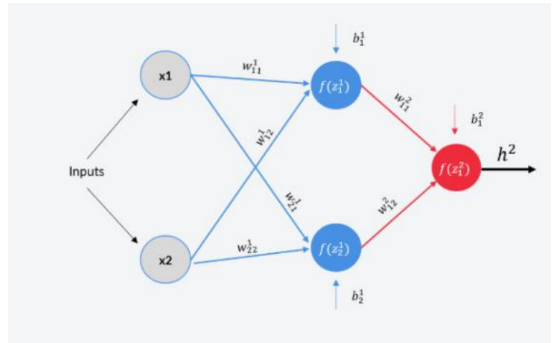

In [51]:
import torch
import torch.nn as nn
import torch.optim as optim

# ===============================
# 1. Training data (y = x1 + x2)
# ===============================
X = torch.tensor([
    [1., 2.],
    [2., 3.],
    [3., 4.],
    [4., 5.]
])

y = torch.tensor([
    [3.],   # 1 + 2
    [5.],   # 2 + 3
    [7.],   # 3 + 4
    [9.]    # 4 + 5
])

# ===============================
# 2. Model definition (2–2–1)
# ===============================
class SimpleRegressionNN(nn.Module):
    def __init__(self):
        super().__init__()
        self.hidden = nn.Linear(2, 2)   # hidden layer
        self.output = nn.Linear(2, 1)   # output layer
        self.relu = nn.ReLU()

    def forward(self, x):
        h = self.relu(self.hidden(x))
        y_hat = self.output(h)          # linear output (NO sigmoid)
        return y_hat

model = SimpleRegressionNN()

# ===============================
# 3. Loss & optimizer
# ===============================
criterion = nn.MSELoss()                       # regression loss
optimizer = optim.Adam(model.parameters(), lr=0.01)

# ===============================
# 4. Training loop
# ===============================
epochs = 5000
for epoch in range(epochs):
    optimizer.zero_grad()
    y_pred = model(X)
    loss = criterion(y_pred, y)
    loss.backward()
    optimizer.step()

# ===============================
# 5. Testing
# ===============================
with torch.no_grad():
    test_input = torch.tensor([[5., 6.]])
    prediction = model(test_input)
    print("Predicted output:", prediction.item())


Predicted output: 11.000208854675293
